> Split from `submission.ipynb`. CCLE modelling notebook. Run after 01_ccle_eda.ipynb, or provide the required processed/ CCLE artifacts.

> Original cell range: `21` to `66`.


# CCLE TP53 Modeling Notebook: RNA-only models with lineage-stratified splits

This notebook follows the assignment literally: predictive features are gene-expression measurements. Lineage is used only for stratified splitting, split-balance audits, and subgroup/grouped evaluation. It is not used as a predictor.


## Notebook outputs

The notebook produces:
- validation and test results for RNA-only Task 1 models;
- a fixed primary RNA model (`rna_enet_logreg`);
- RNA-only model-family ablations and a soft-voting ensemble;
- coefficient-based interpretation of the primary RNA model;
- per-lineage and grouped checks for confounding;
- Task 2 multiclass status/type results from RNA expression;
- strict mutant-only Task 2 metrics computed on TP53-mutant test samples only.


## 0. Setup


In [11]:
from pathlib import Path
import shutil

CWD = Path.cwd()
SEARCH_ROOTS = [
    Path("/kaggle/working"),
    Path("/kaggle/input"),
    Path("/content"),
    Path("/mnt/data"),
    Path("tp53_completed_notebooks"),
]
if str(CWD) not in {"/", "/mnt"} and CWD not in SEARCH_ROOTS:
    SEARCH_ROOTS.insert(0, CWD)

REQUIRED_CCLE_FILES = [
    "ccle_sample_metadata.parquet",
    "ccle_split_membership.parquet",
    "ccle_X_rna_filtered_all.parquet",
    "ccle_modeling_schema.json",
]

OPTIONAL_CCLE_FILES = [
    "ccle_X_meta.parquet",
    "ccle_sure_outliers.txt",
    "ccle_possible_outliers.txt",
]


def processed_dir_is_complete(p, required_files=REQUIRED_CCLE_FILES):
    return p.is_dir() and all((p / f).exists() for f in required_files)


def find_processed_dir(required_files, search_roots):
    candidates = []
    for root in search_roots:
        if not root.exists():
            continue
        direct = root / "processed"
        if processed_dir_is_complete(direct, required_files):
            candidates.append(direct)
        for p in root.rglob("processed"):
            if processed_dir_is_complete(p, required_files):
                candidates.append(p)

    unique = []
    seen = set()
    for p in candidates:
        rp = str(p.resolve())
        if rp not in seen:
            unique.append(p)
            seen.add(rp)

    if not unique:
        visible = []
        for root in search_roots:
            if root.exists():
                for f in root.rglob("*"):
                    if f.is_file():
                        visible.append(str(f))
                        if len(visible) >= 80:
                            break
            if len(visible) >= 80:
                break
        raise FileNotFoundError(
            "Could not find raw CCLE files or a processed/ directory containing the required CCLE artifacts.\n"
            f"Required processed files: {required_files}\n"
            f"Searched roots: {[str(r) for r in search_roots]}\n\n"
            "Attach either the raw CCLE files or a processed/ dataset. First visible files are:\n"
            + "\n".join(visible[:80])
        )
    return unique[0]

SRC_PROCESSED = find_processed_dir(REQUIRED_CCLE_FILES, SEARCH_ROOTS)
DST_PROCESSED = Path("processed")

if SRC_PROCESSED.resolve() == DST_PROCESSED.resolve():
    print(f"Using local processed directory from this run: {DST_PROCESSED.resolve()}")
else:
    if DST_PROCESSED.exists():
        shutil.rmtree(DST_PROCESSED)
    shutil.copytree(SRC_PROCESSED, DST_PROCESSED)
    print(f"Copied CCLE processed files from {SRC_PROCESSED} to writable directory: {DST_PROCESSED.resolve()}")

print("\nRequired processed files:")
for f in REQUIRED_CCLE_FILES:
    print("FOUND" if (DST_PROCESSED / f).exists() else "MISSING", f)

print("\nOptional processed files:")
for f in OPTIONAL_CCLE_FILES:
    print("FOUND" if (DST_PROCESSED / f).exists() else "MISSING", f)

PROCESSED_DIR = DST_PROCESSED


Using local processed directory from this run: /kaggle/working/processed

Required processed files:
FOUND ccle_sample_metadata.parquet
FOUND ccle_split_membership.parquet
FOUND ccle_X_rna_filtered_all.parquet
FOUND ccle_modeling_schema.json

Optional processed files:
MISSING ccle_X_meta.parquet
FOUND ccle_sure_outliers.txt
FOUND ccle_possible_outliers.txt


In [12]:
from pathlib import Path
from IPython.display import display
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.multitest import multipletests

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

RNG = 42
PROC = Path("processed")
PROC.mkdir(exist_ok=True, parents=True)

CONFIG = {
    "primary_model_name": "rna_enet_logreg",
    "primary_label_fallback": "TP53_mut_nonsyn",
    "corr_alpha": 0.05,
    "corr_min_abs_r": 0.15,
    "max_corr_features": 300,
    "selector_fallback_top_n": 200,
    "min_meta_category_n": 15,
    "cv_splits": 3,
    "cv_scoring": "average_precision",
    "bootstrap_reps": 200,
    "grouped_outer_splits": 3,
    "grouped_inner_splits": 2,
    "label_sensitivity_labels": ["TP53_mut_nonsyn", "TP53_mut_lof"],
    "top_k_interpretation": 30,
    "evaluate_optional_rf": False,
    "allow_metadata_predictors": False,
    "run_ccle_ablation": True,
}

TP53_TARGETS = {
    "APAF1", "ATF3", "BAK1", "BAX", "BBC3", "BID", "BTG2", "CASP6", "CCNG1", "CCNG2",
    "CDKN1A", "DDB2", "DRAM1", "EDA2R", "FAS", "FDXR", "FOXO3", "GADD45A", "GADD45B",
    "GDF15", "IGFBP3", "LIF", "LRDD", "MDM2", "MDM4", "NDRG1", "PERP", "PIDD1", "PLK2",
    "PLK3", "PMAIP1", "POLH", "PTEN", "RPS27L", "RRM2B", "RRAD", "SERPINE1", "SESN1",
    "SESN2", "SESN3", "SFN", "SIAH1", "THBS1", "TIGAR", "TNFRSF10B", "TP53AIP1",
    "TP53I3", "TP53INP1", "WIG1", "XPC", "ZMAT3",
}
TARGET_ALIASES = {"WIG1": "ZMAT3"}
LINEAGE_MARKER_HINTS = {"EPCAM", "CLDN7", "KRT8", "KRT18", "KRT19", "MUC1"}

print(json.dumps(CONFIG, indent=2))


{
  "primary_model_name": "rna_enet_logreg",
  "primary_label_fallback": "TP53_mut_nonsyn",
  "corr_alpha": 0.05,
  "corr_min_abs_r": 0.15,
  "max_corr_features": 300,
  "selector_fallback_top_n": 200,
  "min_meta_category_n": 15,
  "cv_splits": 3,
  "cv_scoring": "average_precision",
  "bootstrap_reps": 200,
  "grouped_outer_splits": 3,
  "grouped_inner_splits": 2,
  "label_sensitivity_labels": [
    "TP53_mut_nonsyn",
    "TP53_mut_lof"
  ],
  "top_k_interpretation": 30,
  "evaluate_optional_rf": false,
  "allow_metadata_predictors": false,
  "run_ccle_ablation": true
}


### Helper functions


In [13]:
def load_parquet_with_id(path, id_col="ModelID"):
    df = pd.read_parquet(path)
    if id_col not in df.columns:
        raise ValueError(f"{path} is missing required ID column {id_col}")
    df[id_col] = df[id_col].astype(str)
    return df.set_index(id_col)


def save_parquet_with_id(df, filename, id_col="ModelID"):
    out = df.copy()
    out.insert(0, id_col, out.index.astype(str))
    out.to_parquet(PROC / filename, index=False)


def save_series_with_id(s, filename, value_name=None, id_col="ModelID"):
    s = s.copy()
    if value_name is not None:
        s.name = value_name
    s.rename_axis(id_col).reset_index().to_parquet(PROC / filename, index=False)


def make_dense_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def corr_against_binary(X, y, method="pearson"):
    if not isinstance(X, pd.DataFrame):
        raise TypeError("corr_against_binary expects a pandas DataFrame")
    y = pd.Series(y, index=X.index).astype(float)
    assert X.index.equals(y.index), "X and y must have aligned indices."

    y_vec = y.to_numpy()
    cols = X.columns

    if method == "spearman":
        X_use = X.rank(axis=0, method="average").to_numpy(dtype=float)
        y_use = pd.Series(y_vec, index=y.index).rank(method="average").to_numpy(dtype=float)
    else:
        X_use = X.to_numpy(dtype=float)
        y_use = y_vec.astype(float)

    x_std = X_use.std(axis=0, ddof=1)
    valid = x_std > 0
    valid_cols = cols[valid]

    out = pd.DataFrame(index=cols)
    out[f"{method}_r"] = np.nan
    out[f"{method}_p"] = np.nan
    out[f"{method}_p_bh"] = np.nan

    if valid.sum() == 0:
        return out

    Xv = X_use[:, valid]
    yc = y_use - y_use.mean()
    Xc = Xv - Xv.mean(axis=0, keepdims=True)

    denom = np.sqrt((Xc ** 2).sum(axis=0) * (yc ** 2).sum())
    r = (Xc * yc[:, None]).sum(axis=0) / np.clip(denom, 1e-12, None)

    n = len(y_use)
    t_stat = r * np.sqrt((n - 2) / np.clip(1 - r ** 2, 1e-12, None))
    p = 2 * stats.t.sf(np.abs(t_stat), df=n - 2)
    p_bh = multipletests(p, method="fdr_bh")[1]

    out.loc[valid_cols, f"{method}_r"] = r
    out.loc[valid_cols, f"{method}_p"] = p
    out.loc[valid_cols, f"{method}_p_bh"] = p_bh
    return out


def get_prob(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        score = estimator.decision_function(X)
        return 1 / (1 + np.exp(-score))
    raise AttributeError("Estimator has neither predict_proba nor decision_function")


def choose_threshold(y_true, prob):
    thresholds = np.unique(np.round(prob, 6))
    if len(thresholds) == 0:
        return 0.5
    thresholds = np.concatenate([[0.0], thresholds, [1.0]])
    best_thr, best_score = 0.5, -np.inf
    for thr in thresholds:
        pred = (prob >= thr).astype(int)
        score = balanced_accuracy_score(y_true, pred)
        if score > best_score:
            best_thr, best_score = thr, score
    return float(best_thr)


def evaluate_binary_metrics(y_true, prob, threshold=0.5):
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "auroc": roc_auc_score(y_true, prob),
        "auprc": average_precision_score(y_true, prob),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "f1": f1_score(y_true, pred, zero_division=0),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "specificity": tn / max(tn + fp, 1),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "threshold": float(threshold),
    }


def bootstrap_metric_ci(y_true, prob, metric_fn, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    prob = np.asarray(prob)
    vals = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yb = y_true[idx]
        if len(np.unique(yb)) < 2:
            continue
        vals.append(metric_fn(yb, prob[idx]))
    if len(vals) == 0:
        return (np.nan, np.nan, np.nan)
    vals = np.asarray(vals, dtype=float)
    return float(np.mean(vals)), float(np.quantile(vals, 0.025)), float(np.quantile(vals, 0.975))


### Custom transformers and feature builders


In [14]:
class CorrTargetGeneSelector(BaseEstimator, TransformerMixin):
    """Fold-safe supervised selector for mRNA features."""

    def __init__(
        self,
        corr_alpha=0.05,
        corr_min_abs_r=0.15,
        max_corr_features=300,
        fallback_top_n=200,
        tp53_targets=None,
        target_aliases=None,
    ):
        self.corr_alpha = corr_alpha
        self.corr_min_abs_r = corr_min_abs_r
        self.max_corr_features = max_corr_features
        self.fallback_top_n = fallback_top_n
        self.tp53_targets = tp53_targets
        self.target_aliases = target_aliases

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("CorrTargetGeneSelector expects a pandas DataFrame")

        tp53_targets = set() if self.tp53_targets is None else set(self.tp53_targets)
        target_aliases = {} if self.target_aliases is None else dict(self.target_aliases)

        y = pd.Series(y, index=X.index).astype(int)
        pear = corr_against_binary(X, y, method="pearson")
        spear = corr_against_binary(X, y, method="spearman")
        corr = pear.join(spear)
        corr["abs_pearson_r"] = corr["pearson_r"].abs()
        corr["abs_spearman_r"] = corr["spearman_r"].abs()

        strict_ranked = corr.loc[
            (corr["pearson_p_bh"] <= self.corr_alpha)
            & (corr["spearman_p_bh"] <= self.corr_alpha)
            & (corr["abs_pearson_r"] >= self.corr_min_abs_r)
        ].sort_values("abs_pearson_r", ascending=False)

        if len(strict_ranked) == 0:
            strict_ranked = corr.sort_values("abs_pearson_r", ascending=False).head(self.fallback_top_n)

        corr_genes = set(strict_ranked.head(self.max_corr_features).index)

        targets_present = set()
        for gene in sorted(tp53_targets):
            if gene in X.columns:
                targets_present.add(gene)
            elif gene in target_aliases and target_aliases[gene] in X.columns:
                targets_present.add(target_aliases[gene])

        selected = sorted(corr_genes | targets_present)
        if len(selected) == 0:
            raise ValueError("Selector produced zero genes; inspect the fold or relax thresholds.")

        self.selected_genes_ = selected
        self.corr_table_ = corr.sort_values("abs_pearson_r", ascending=False)
        self.selection_manifest_ = pd.DataFrame(index=selected)
        self.selection_manifest_["from_correlation"] = self.selection_manifest_.index.isin(corr_genes)
        self.selection_manifest_["from_tp53_target_list"] = self.selection_manifest_.index.isin(targets_present)
        self.selection_manifest_["pearson_r"] = corr.reindex(self.selection_manifest_.index)["pearson_r"]
        self.selection_manifest_["abs_pearson_r"] = self.selection_manifest_["pearson_r"].abs()
        self.selection_manifest_ = self.selection_manifest_.sort_values("abs_pearson_r", ascending=False)
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("CorrTargetGeneSelector expects a pandas DataFrame")
        return X.loc[:, self.selected_genes_]

    def get_feature_names_out(self, input_features=None):
        return np.array(self.selected_genes_, dtype=object)

class RNAFeatureBuilder(BaseEstimator, TransformerMixin):
    """Fold-safe supervised RNA feature builder with scaling."""

    def __init__(
        self,
        rna_cols,
        corr_alpha=0.05,
        corr_min_abs_r=0.15,
        max_corr_features=300,
        fallback_top_n=200,
        tp53_targets=None,
        target_aliases=None,
    ):
        self.rna_cols = rna_cols
        self.corr_alpha = corr_alpha
        self.corr_min_abs_r = corr_min_abs_r
        self.max_corr_features = max_corr_features
        self.fallback_top_n = fallback_top_n
        self.tp53_targets = tp53_targets
        self.target_aliases = target_aliases

    def fit(self, X, y):
        X_df = self._to_frame(X)
        rna_cols = list(self.rna_cols)

        gene_df = X_df.loc[:, rna_cols]
        self.selector_ = CorrTargetGeneSelector(
            corr_alpha=self.corr_alpha,
            corr_min_abs_r=self.corr_min_abs_r,
            max_corr_features=self.max_corr_features,
            fallback_top_n=self.fallback_top_n,
            tp53_targets=self.tp53_targets,
            target_aliases=self.target_aliases,
        )
        self.selector_.fit(gene_df, y)
        selected_df = self.selector_.transform(gene_df)

        self.scaler_ = StandardScaler()
        self.scaler_.fit(selected_df)

        self.rna_cols_ = rna_cols
        self.feature_names_out_ = self.selector_.get_feature_names_out()
        return self

    def transform(self, X):
        X_df = self._to_frame(X)
        gene_df = X_df.loc[:, self.rna_cols_]
        selected_df = self.selector_.transform(gene_df)
        return self.scaler_.transform(selected_df)

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_out_

    @staticmethod
    def _to_frame(X):
        if isinstance(X, pd.DataFrame):
            return X
        raise TypeError("RNAFeatureBuilder expects a pandas DataFrame")


### Pipeline factories


In [15]:
def make_rna_pipeline(clf, rna_cols):
    return Pipeline(
        steps=[
            (
                "features",
                RNAFeatureBuilder(
                    rna_cols=rna_cols,
                    corr_alpha=CONFIG["corr_alpha"],
                    corr_min_abs_r=CONFIG["corr_min_abs_r"],
                    max_corr_features=CONFIG["max_corr_features"],
                    fallback_top_n=CONFIG["selector_fallback_top_n"],
                    tp53_targets=TP53_TARGETS,
                    target_aliases=TARGET_ALIASES,
                ),
            ),
            ("clf", clf),
        ]
    )


## 1. Label definition and task alignment

**Primary prediction target:** sample-level `TP53_mut_nonsyn`

This target is derived upstream from raw somatic mutation rows where `HugoSymbol == "TP53"` in the mutation file.

The raw TP53 mutation annotations reviewed in the EDA are:
- `HugoSymbol`
- `VariantType`
- `VariantInfo`
- `DNAChange`
- `ProteinChange`

At the sample level:
- positive class = TP53 protein-altering events (`lof_or_splice` or `missense_or_inframe`)
- negative class = samples without those TP53 protein-altering events
- ambiguous / non-protein-altering TP53 calls are tracked separately for sensitivity analysis

Important: mutation annotation columns are used only to define the target upstream, not as model input features.

## 1. Load processed artifacts from the EDA notebook

In [16]:
required = [
    PROC / "ccle_sample_metadata.parquet",
    PROC / "ccle_X_rna_filtered_all.parquet",
    PROC / "ccle_modeling_schema.json",
]
for path in required:
    assert path.exists(), f"Missing required processed artifact: {path}"

sample_meta = load_parquet_with_id(PROC / "ccle_sample_metadata.parquet")
X_rna = load_parquet_with_id(PROC / "ccle_X_rna_filtered_all.parquet")

with open(PROC / "ccle_modeling_schema.json") as f:
    schema = json.load(f)

primary_label = schema.get("primary_label", CONFIG["primary_label_fallback"])
assert primary_label in sample_meta.columns, f"Primary label {primary_label} not found in sample metadata"

y = sample_meta[primary_label].astype(int)
common = sample_meta.index.intersection(X_rna.index)

sample_meta = sample_meta.loc[common].copy()
X_rna = X_rna.loc[common].copy()
y = y.loc[common].copy()

available_meta_cols = [c for c in schema.get("available_meta_cols", []) if c in sample_meta.columns]
recommended_meta_cols = []  # metadata predictors disabled; lineage is used only for strata/audits
lineage_col = schema.get("lineage_col") if schema.get("lineage_col") in sample_meta.columns else None
sex_col = schema.get("sex_col") if schema.get("sex_col") in sample_meta.columns else None
disease_col = schema.get("disease_col") if schema.get("disease_col") in sample_meta.columns else None

X_joint = X_rna.copy()  # predictors are RNA-only
rna_cols = X_rna.columns.tolist()

# Reconstruct the primary CCLE train/val/test split from processed artifacts so Kaggle
# processed-only runs do not inherit an older, non-lineage-stratified split.
PRIMARY_TEST_SIZE = 0.15
PRIMARY_VAL_SIZE_WITHIN_TEMP = 0.17647058823529413  # gives ~70/15/15 overall

if lineage_col is not None and lineage_col in sample_meta.columns:
    ccle_split_strata_all = make_stable_joint_strata(
        labels=y,
        groups=sample_meta[lineage_col],
        min_count=2,
        group_name="lineage",
        split_fraction=PRIMARY_TEST_SIZE,
        min_group_count=15,
    )
    ccle_split_note = f"TP53 label x {lineage_col}"
else:
    ccle_split_strata_all = y.astype(str)
    ccle_split_note = "TP53 label only; lineage unavailable"

idx_temp, idx_test = train_test_split(
    y.index,
    test_size=PRIMARY_TEST_SIZE,
    stratify=ccle_split_strata_all,
    random_state=RNG,
)
idx_temp = pd.Index(idx_temp, name=y.index.name)
idx_test = pd.Index(idx_test, name=y.index.name)

temp_groups = sample_meta.loc[idx_temp, lineage_col] if lineage_col is not None and lineage_col in sample_meta.columns else pd.Series("missing", index=idx_temp)
ccle_split_strata_temp = make_stable_joint_strata(
    labels=y.loc[idx_temp],
    groups=temp_groups,
    min_count=2,
    group_name="lineage",
    split_fraction=PRIMARY_VAL_SIZE_WITHIN_TEMP,
    min_group_count=15,
)

idx_train, idx_val = train_test_split(
    idx_temp,
    test_size=PRIMARY_VAL_SIZE_WITHIN_TEMP,
    stratify=ccle_split_strata_temp,
    random_state=RNG,
)
idx_train = pd.Index(idx_train, name=y.index.name)
idx_val = pd.Index(idx_val, name=y.index.name)

split_membership = pd.Series(index=y.index, dtype="object")
split_membership.loc[idx_train] = "train"
split_membership.loc[idx_val] = "val"
split_membership.loc[idx_test] = "test"
sample_meta["split"] = split_membership

train_idx = split_membership.index[split_membership.eq("train")]
val_idx = split_membership.index[split_membership.eq("val")]
test_idx = split_membership.index[split_membership.eq("test")]
trainval_idx = split_membership.index[split_membership.isin(["train", "val"])]

X_train = X_joint.loc[train_idx]
X_val = X_joint.loc[val_idx]
X_test = X_joint.loc[test_idx]
X_trainval = X_joint.loc[trainval_idx]

y_train = y.loc[train_idx]
y_val = y.loc[val_idx]
y_test = y.loc[test_idx]
y_trainval = y.loc[trainval_idx]

print(f"Primary label: {primary_label}")
print(f"Primary CCLE split stratification: {ccle_split_note}")
print(f"Samples -> train: {len(train_idx)}, val: {len(val_idx)}, test: {len(test_idx)}")
print(f"RNA genes available: {len(rna_cols):,}")
print(f"Metadata columns available for strata/audits only: {available_meta_cols}")
print("Metadata columns used as predictors: []")

display(pd.DataFrame({
    "n": [len(train_idx), len(val_idx), len(test_idx)],
    "tp53_mut_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
}, index=["train", "val", "test"]).round(3))

if lineage_col is not None and lineage_col in sample_meta.columns:
    print("CCLE lineage distribution across reconstructed splits, top 20:")
    display(pd.crosstab(sample_meta[lineage_col].fillna("Unknown"), split_membership).sort_values("train", ascending=False).head(20))


Using adaptive TP53-label x lineage strata: 50 strata; rare lineage threshold=15. No samples dropped.
Using adaptive TP53-label x lineage strata: 50 strata; rare lineage threshold=15. No samples dropped.
Primary label: TP53_mut_nonsyn
Primary CCLE split stratification: TP53 label x OncotreeLineage
Samples -> train: 1124, val: 242, test: 242
RNA genes available: 17,781
Metadata columns available for strata/audits only: ['OncotreeLineage', 'Sex', 'OncotreePrimaryDisease']
Metadata columns used as predictors: []


,n,tp53_mut_rate
train,1124,0.613
val,242,0.616
test,242,0.616


CCLE lineage distribution across reconstructed splits, top 20:


col_0,test,train,val
OncotreeLineage,,,
Lung,30,139,30
Lymphoid,28,128,28
Skin,18,83,18
CNS/Brain,14,67,14
Bowel,13,58,13
Esophagus/Stomach,12,54,12
Head and Neck,11,51,11
Myeloid,10,51,10
Breast,10,49,10


In [17]:
# Label provenance checks and leakage guard

FORBIDDEN_LABEL_SOURCE_COLS = {"HugoSymbol", "VariantType", "VariantInfo", "DNAChange", "ProteinChange"}

predictor_cols = set(X_joint.columns)
leaky_predictors = sorted(FORBIDDEN_LABEL_SOURCE_COLS.intersection(predictor_cols))
assert len(leaky_predictors) == 0, f"Forbidden mutation-label source columns leaked into predictors: {leaky_predictors}"

if "TP53_mut_ambiguous" not in sample_meta.columns:
    if "TP53_event_class" in sample_meta.columns:
        sample_meta["TP53_mut_ambiguous"] = sample_meta["TP53_event_class"].isin(
            ["other_or_unknown", "unknown", "synonymous"]
        ).astype(int)
    else:
        sample_meta["TP53_mut_ambiguous"] = 0

label_summary = pd.Series(
    {
        "primary_label": primary_label,
        "n_total": len(sample_meta),
        "primary_positive_n": int(sample_meta[primary_label].sum()),
        "primary_positive_rate": float(sample_meta[primary_label].mean()),
        "ambiguous_tp53_n": int(sample_meta["TP53_mut_ambiguous"].sum()),
        "multi_event_tp53_n": int((sample_meta.get("tp53_event_count", pd.Series(0, index=sample_meta.index)) > 1).sum()),
    },
    name="value",
)
display(label_summary.to_frame())

if "TP53_event_class" in sample_meta.columns:
    event_class_counts = (
        sample_meta["TP53_event_class"]
        .fillna("wild_type")
        .value_counts(dropna=False)
        .rename_axis("TP53_event_class")
        .to_frame("n_cell_lines")
    )
    display(event_class_counts)

,value
primary_label,TP53_mut_nonsyn
n_total,1608
primary_positive_n,987
primary_positive_rate,0.613806
ambiguous_tp53_n,0
multi_event_tp53_n,115


,n_cell_lines
TP53_event_class,
missense_or_inframe,625
wild_type,621
lof_or_splice,362


## 2. Build the RNA-only model registry

The model registry is intentionally restricted to RNA-expression predictors. Lineage and other metadata are not included as model features; they are used only for stratification and subgroup evaluation.


In [18]:
cv = StratifiedKFold(n_splits=CONFIG["cv_splits"], shuffle=True, random_state=RNG)

registry = []

registry.append(
    {
        "model_name": "dummy_prior",
        "tier": "baseline",
        "meta_cols": [],
        "estimator": DummyClassifier(strategy="prior"),
        "param_grid": {},
    }
)

registry.append(
    {
        "model_name": "rna_enet_logreg",
        "tier": "mrna",
        "meta_cols": [],
        "estimator": make_rna_pipeline(
            LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                max_iter=6000,
                class_weight="balanced",
                random_state=RNG,
            ),
            rna_cols=rna_cols,
        ),
        "param_grid": {"clf__C": [0.1, 1.0], "clf__l1_ratio": [0.0, 0.5]},
    }
)

registry.append(
    {
        "model_name": "rna_l2_logreg",
        "tier": "mrna",
        "meta_cols": [],
        "estimator": make_rna_pipeline(
            LogisticRegression(
                penalty="l2",
                solver="liblinear",
                max_iter=6000,
                class_weight="balanced",
                random_state=RNG,
            ),
            rna_cols=rna_cols,
        ),
        "param_grid": {"clf__C": [0.1, 1.0]},
    }
)

registry.append(
    {
        "model_name": "rna_linear_svm",
        "tier": "mrna",
        "meta_cols": [],
        "estimator": make_rna_pipeline(
            SVC(kernel="linear", probability=True, class_weight="balanced", random_state=RNG),
            rna_cols=rna_cols,
        ),
        "param_grid": {"clf__C": [0.1, 1.0]},
    }
)

if CONFIG.get("evaluate_optional_rf", False):
    from sklearn.ensemble import RandomForestClassifier
    registry.append(
        {
            "model_name": "rna_random_forest",
            "tier": "appendix",
            "meta_cols": [],
            "estimator": make_rna_pipeline(
                RandomForestClassifier(
                    n_estimators=200,
                    class_weight="balanced_subsample",
                    random_state=RNG,
                    n_jobs=-1,
                ),
                rna_cols=rna_cols,
            ),
            "param_grid": {"clf__max_depth": [None, 8], "clf__min_samples_leaf": [1, 3]},
        }
    )

# Safety guard: metadata must not be registered as a predictor in the submission notebook.
non_rna_tiers = {r["tier"] for r in registry} - {"baseline", "mrna", "appendix"}
assert not non_rna_tiers, f"Unexpected metadata/joint predictor tiers were registered: {non_rna_tiers}"
assert all(len(r.get("meta_cols", [])) == 0 for r in registry), "Metadata predictors are disabled; found non-empty meta_cols."

registry_df = pd.DataFrame(
    [{"model_name": r["model_name"], "tier": r["tier"], "meta_cols": ""} for r in registry]
)
print("Registered Task 1 models: RNA-only predictors plus dummy baseline.")
display(registry_df)


Registered Task 1 models: RNA-only predictors plus dummy baseline.


,model_name,tier,meta_cols
0,dummy_prior,baseline,
1,rna_enet_logreg,mrna,
2,rna_l2_logreg,mrna,
3,rna_linear_svm,mrna,


## 3. Train on the training split and rank on validation


In [19]:
val_rows = []
val_prob_store = {}
val_best_params = {}
trained_on_train = {}

for spec in registry:
    model_name = spec["model_name"]
    estimator = spec["estimator"]
    param_grid = spec["param_grid"]

    if len(param_grid) == 0:
        estimator.fit(X_train, y_train)
        best_est = estimator
        best_params = {}
        best_cv = np.nan
    else:
        grid = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            scoring=CONFIG["cv_scoring"],
            cv=cv,
            n_jobs=-1,
            refit=True,
        )
        grid.fit(X_train, y_train)
        best_est = grid.best_estimator_
        best_params = grid.best_params_
        best_cv = grid.best_score_

    prob_val = get_prob(best_est, X_val)
    thr = choose_threshold(y_val, prob_val)
    metrics = evaluate_binary_metrics(y_val, prob_val, threshold=thr)

    row = {
        "model_name": model_name,
        "tier": spec["tier"],
        "meta_cols": ", ".join(spec["meta_cols"]),
        "cv_best_score": best_cv,
        "best_params": json.dumps(best_params),
    }
    row.update({f"val_{k}": v for k, v in metrics.items()})
    val_rows.append(row)

    val_prob_store[model_name] = prob_val
    val_best_params[model_name] = best_params
    trained_on_train[model_name] = best_est

val_results = pd.DataFrame(val_rows).sort_values(["tier", "val_auprc"], ascending=[True, False]).reset_index(drop=True)
display(val_results.round(4))

PRIMARY_MODEL_NAME = CONFIG["primary_model_name"]
assert PRIMARY_MODEL_NAME in val_results["model_name"].values, f"Primary model {PRIMARY_MODEL_NAME} missing from validation results"

best_meta_model = None
best_joint_model = None

print(f"Primary RNA model (fixed): {PRIMARY_MODEL_NAME}")
print("Metadata-only and RNA+metadata models are not trained in this submission notebook.")


,model_name,tier,meta_cols,cv_best_score,best_params,val_auroc,val_auprc,val_balanced_accuracy,val_f1,val_precision,val_recall,val_specificity,val_tn,val_fp,val_fn,val_tp,val_threshold
0,dummy_prior,baseline,,NaN,{},0.5000,0.6157,0.5000,0.7621,0.6157,1.0000,0.0000,0,93,0,149,0.0000
1,rna_enet_logreg,mrna,,0.9277,"{""clf__C"": 0.1, ""clf__l1_ratio"": 0.5}",0.9156,0.9189,0.8824,0.9139,0.9020,0.9262,0.8387,78,15,11,138,0.4679
2,rna_l2_logreg,mrna,,0.9221,"{""clf__C"": 0.1}",0.9030,0.9150,0.8630,0.9013,0.8839,0.9195,0.8065,75,18,12,137,0.4201
3,rna_linear_svm,mrna,,0.8972,"{""clf__C"": 0.1}",0.8808,0.8889,0.8401,0.8852,0.8654,0.9060,0.7742,72,21,14,135,0.5513


Primary RNA model (fixed): rna_enet_logreg
Metadata-only and RNA+metadata models are not trained in this submission notebook.


## 4. Refit on train + validation and evaluate once on test


In [20]:
test_rows = []
test_prob_store = {}
trained_on_trainval = {}

for spec in registry:
    model_name = spec["model_name"]
    est = clone(spec["estimator"]) if spec["model_name"] != "dummy_prior" else clone(spec["estimator"])
    if len(val_best_params[model_name]) > 0:
        est.set_params(**val_best_params[model_name])
    est.fit(X_trainval, y_trainval)

    prob_test = get_prob(est, X_test)
    val_thr = float(val_results.loc[val_results["model_name"].eq(model_name), "val_threshold"].iloc[0])
    metrics = evaluate_binary_metrics(y_test, prob_test, threshold=val_thr)

    row = {
        "model_name": model_name,
        "tier": spec["tier"],
        "meta_cols": ", ".join(spec["meta_cols"]),
        "val_threshold": val_thr,
    }
    row.update({f"test_{k}": v for k, v in metrics.items()})
    test_rows.append(row)

    test_prob_store[model_name] = prob_test
    trained_on_trainval[model_name] = est

test_results = pd.DataFrame(test_rows).sort_values(["tier", "test_auprc"], ascending=[True, False]).reset_index(drop=True)
display(test_results.round(4))


,model_name,tier,meta_cols,val_threshold,test_auroc,test_auprc,test_balanced_accuracy,test_f1,test_precision,test_recall,test_specificity,test_tn,test_fp,test_fn,test_tp,test_threshold
0,dummy_prior,baseline,,0.0000,0.5000,0.6157,0.5000,0.7621,0.6157,1.0000,0.0000,0,93,0,149,0.0000
1,rna_enet_logreg,mrna,,0.4679,0.8956,0.9264,0.8280,0.8750,0.8581,0.8926,0.7634,71,22,16,133,0.4679
2,rna_l2_logreg,mrna,,0.4201,0.8744,0.9057,0.8280,0.8750,0.8581,0.8926,0.7634,71,22,16,133,0.4201
3,rna_linear_svm,mrna,,0.5513,0.8581,0.8843,0.8005,0.8505,0.8421,0.8591,0.7419,69,24,21,128,0.5513


## 5. Main comparison table: dummy baseline vs RNA-only model


In [21]:
def get_row(df, model_name, prefix):
    row = df.loc[df["model_name"].eq(model_name)].iloc[0].copy()
    keep = [c for c in row.index if c in ["model_name", "tier", "meta_cols"] or c.startswith(prefix)]
    return row[keep]

main_models = ["dummy_prior", PRIMARY_MODEL_NAME]

main_validation_table = pd.concat([get_row(val_results, m, "val_") for m in main_models], axis=1).T.reset_index(drop=True)
main_test_table = pd.concat([get_row(test_results, m, "test_") for m in main_models], axis=1).T.reset_index(drop=True)

main_comparison = main_test_table[["model_name", "tier", "meta_cols", "test_auroc", "test_auprc", "test_balanced_accuracy", "test_f1", "test_precision", "test_recall", "test_specificity"]].copy()

base_auprc = float(main_comparison.loc[main_comparison["model_name"].eq("dummy_prior"), "test_auprc"].iloc[0])
mrna_auprc = float(main_comparison.loc[main_comparison["model_name"].eq(PRIMARY_MODEL_NAME), "test_auprc"].iloc[0])
main_comparison["delta_auprc_vs_dummy"] = main_comparison["test_auprc"] - base_auprc
main_comparison["delta_auprc_vs_mrna"] = main_comparison["test_auprc"] - mrna_auprc

display(main_comparison.round(4))


,model_name,tier,meta_cols,test_auroc,test_auprc,test_balanced_accuracy,test_f1,test_precision,test_recall,test_specificity,delta_auprc_vs_dummy,delta_auprc_vs_mrna
0,dummy_prior,baseline,,0.5,0.615702,0.5,0.762148,0.615702,1.0,0.0,0.0,-0.310733
1,rna_enet_logreg,mrna,,0.895576,0.926435,0.828029,0.875,0.858065,0.892617,0.763441,0.310733,0.0



## 5A. RNA model-family ablation and soft-voting ensemble

This section mirrors the TCGA ablation table for the CCLE branch. It keeps the same leakage-aware structure as the main notebook: RNA feature selection and scaling are fit only inside the current training fold, hyperparameters are selected on the training split by inner-CV AUPRC, the validation split is used only for model ranking and threshold selection, and the test split is evaluated once after refitting on train + validation.

The purpose is not to replace the fixed primary elastic-net logistic model, but to check whether the main conclusion depends strongly on one model family.


Implementation note: the PCA ablation uses a version-safe cuML PCA constructor because Kaggle RAPIDS builds differ in whether `random_state` and `output_type` are accepted. RBF SVC is disabled by default because it is slower and more version-sensitive; set `CCLE_ABLATION_INCLUDE_SVC = True` only if you want to include it.

In [22]:
# ============================================================
# CCLE RNA-only model-family ablation, CPU/Kaggle compatible
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

RUN_CCLE_ABLATION = True
CCLE_ABLATION_ENSEMBLE_TOP_N = 3

ccle_ablation_cv_results = pd.DataFrame()
ccle_ablation_table = None
ccle_ablation_table_with_ensemble = None
ccle_final_model_comparison_with_ablations = None
ccle_ablation_val_prob_store = {}
ccle_ablation_test_prob_store = {}

if RUN_CCLE_ABLATION:
    ablation_specs = [
        {
            "model_name": "ablation_enet_logreg",
            "estimator": make_rna_pipeline(
                LogisticRegression(penalty="elasticnet", solver="saga", max_iter=6000, class_weight="balanced", random_state=RNG),
                rna_cols=rna_cols,
            ),
            "param_grid": {"clf__C": [0.1, 1.0], "clf__l1_ratio": [0.0, 0.5]},
        },
        {
            "model_name": "ablation_l2_logreg",
            "estimator": make_rna_pipeline(
                LogisticRegression(penalty="l2", solver="liblinear", max_iter=5000, class_weight="balanced", random_state=RNG),
                rna_cols=rna_cols,
            ),
            "param_grid": {"clf__C": [0.1, 1.0]},
        },
        {
            "model_name": "ablation_linear_svm",
            "estimator": make_rna_pipeline(
                SVC(kernel="linear", probability=True, class_weight="balanced", random_state=RNG),
                rna_cols=rna_cols,
            ),
            "param_grid": {"clf__C": [0.1, 1.0]},
        },
        {
            "model_name": "ablation_random_forest_fast",
            "estimator": make_rna_pipeline(
                RandomForestClassifier(n_estimators=150, max_features="sqrt", class_weight="balanced_subsample", random_state=RNG, n_jobs=-1),
                rna_cols=rna_cols,
            ),
            "param_grid": {"clf__max_depth": [8, None], "clf__min_samples_leaf": [2]},
        },
        {
            "model_name": "ablation_knn_fast",
            "estimator": make_rna_pipeline(KNeighborsClassifier(), rna_cols=rna_cols),
            "param_grid": {"clf__n_neighbors": [15, 31]},
        },
    ]

    rows = []
    cv_frames = []
    for spec in ablation_specs:
        name = spec["model_name"]
        print(f"Running RNA-only ablation: {name}")
        search = GridSearchCV(
            estimator=clone(spec["estimator"]),
            param_grid=spec["param_grid"],
            scoring=CONFIG["cv_scoring"],
            cv=cv,
            n_jobs=-1,
            refit=True,
        )
        search.fit(X_train, y_train)
        cv_frame = pd.DataFrame(search.cv_results_)
        cv_frame["model_name"] = name
        cv_frames.append(cv_frame)

        val_prob = get_prob(search.best_estimator_, X_val)
        val_thr = choose_threshold(y_val, val_prob)
        val_metrics = evaluate_binary_metrics(y_val, val_prob, threshold=val_thr)

        refit_est = clone(spec["estimator"])
        refit_est.set_params(**search.best_params_)
        refit_est.fit(X_trainval, y_trainval)
        test_prob = get_prob(refit_est, X_test)
        test_metrics = evaluate_binary_metrics(y_test, test_prob, threshold=val_thr)

        ccle_ablation_val_prob_store[name] = val_prob
        ccle_ablation_test_prob_store[name] = test_prob

        row = {
            "model_name": name,
            "tier": "rna_ablation",
            "selection_rule": "inner-CV AUPRC on train; threshold selected on validation",
            "cv_best_score": float(search.best_score_),
            "best_params": json.dumps(search.best_params_),
        }
        row.update({f"val_{k}": v for k, v in val_metrics.items()})
        row.update({f"test_{k}": v for k, v in test_metrics.items()})
        rows.append(row)

    ccle_ablation_cv_results = pd.concat(cv_frames, ignore_index=True) if cv_frames else pd.DataFrame()
    ccle_ablation_table = pd.DataFrame(rows).sort_values("val_auprc", ascending=False).reset_index(drop=True)

    ensemble_members = ccle_ablation_table.head(CCLE_ABLATION_ENSEMBLE_TOP_N)["model_name"].tolist()
    print("Soft-voting ensemble members selected by validation AUPRC:", ensemble_members)

    ensemble_val_prob = np.mean([ccle_ablation_val_prob_store[m] for m in ensemble_members], axis=0)
    ensemble_thr = choose_threshold(y_val, ensemble_val_prob)
    ensemble_val_metrics = evaluate_binary_metrics(y_val, ensemble_val_prob, threshold=ensemble_thr)

    ensemble_test_prob = np.mean([ccle_ablation_test_prob_store[m] for m in ensemble_members], axis=0)
    ensemble_test_metrics = evaluate_binary_metrics(y_test, ensemble_test_prob, threshold=ensemble_thr)

    ensemble_row = {
        "model_name": "soft_vote_top_rna_ablation_models",
        "tier": "rna_ablation_ensemble",
        "selection_rule": f"top {len(ensemble_members)} RNA-only ablation models by validation AUPRC; uniform probability average",
        "cv_best_score": float(ccle_ablation_table.head(len(ensemble_members))["cv_best_score"].mean()),
        "best_params": json.dumps({"members": ensemble_members, "weights": "uniform"}),
    }
    ensemble_row.update({f"val_{k}": v for k, v in ensemble_val_metrics.items()})
    ensemble_row.update({f"test_{k}": v for k, v in ensemble_test_metrics.items()})

    ccle_ablation_table_with_ensemble = pd.concat([ccle_ablation_table, pd.DataFrame([ensemble_row])], ignore_index=True).sort_values("val_auprc", ascending=False).reset_index(drop=True)

    display(ccle_ablation_table_with_ensemble[[
        "model_name", "tier", "cv_best_score", "val_auprc", "test_auprc", "test_auroc",
        "test_balanced_accuracy", "test_f1", "test_precision", "test_recall", "best_params"
    ]].round(4))
else:
    print("Skipping CCLE ablation table because RUN_CCLE_ABLATION is False.")


Running RNA-only ablation: ablation_enet_logreg
Running RNA-only ablation: ablation_l2_logreg
Running RNA-only ablation: ablation_linear_svm
Running RNA-only ablation: ablation_random_forest_fast
Running RNA-only ablation: ablation_knn_fast
Soft-voting ensemble members selected by validation AUPRC: ['ablation_random_forest_fast', 'ablation_enet_logreg', 'ablation_l2_logreg']


,model_name,tier,cv_best_score,val_auprc,test_auprc,test_auroc,test_balanced_accuracy,test_f1,test_precision,test_recall,best_params
0,ablation_random_forest_fast,rna_ablation,0.9229,0.9456,0.9321,0.9005,0.8173,0.8693,0.8471,0.8926,"{""clf__max_depth"": null, ""clf__min_samples_lea..."
1,soft_vote_top_rna_ablation_models,rna_ablation_ensemble,0.9242,0.9343,0.9266,0.8952,0.8321,0.8733,0.8675,0.8792,"{""members"": [""ablation_random_forest_fast"", ""a..."
2,ablation_enet_logreg,rna_ablation,0.9277,0.9189,0.9264,0.8956,0.8280,0.8750,0.8581,0.8926,"{""clf__C"": 0.1, ""clf__l1_ratio"": 0.5}"
3,ablation_l2_logreg,rna_ablation,0.9221,0.9150,0.9057,0.8744,0.8280,0.8750,0.8581,0.8926,"{""clf__C"": 0.1}"
4,ablation_knn_fast,rna_ablation,0.8875,0.9080,0.9008,0.8660,0.7857,0.8299,0.8414,0.8188,"{""clf__n_neighbors"": 31}"
5,ablation_linear_svm,rna_ablation,0.8972,0.8889,0.8843,0.8581,0.8005,0.8505,0.8421,0.8591,"{""clf__C"": 0.1}"


## 6. Bootstrap confidence intervals for the headline models


In [23]:
ci_rows = []
for model_name in main_models:
    prob = test_prob_store[model_name]
    ap_mean, ap_lo, ap_hi = bootstrap_metric_ci(y_test.to_numpy(), prob, average_precision_score, n_boot=CONFIG["bootstrap_reps"], seed=RNG)
    roc_mean, roc_lo, roc_hi = bootstrap_metric_ci(y_test.to_numpy(), prob, roc_auc_score, n_boot=CONFIG["bootstrap_reps"], seed=RNG + 1)
    ci_rows.append(
        {
            "model_name": model_name,
            "auprc_mean": ap_mean,
            "auprc_ci_lo": ap_lo,
            "auprc_ci_hi": ap_hi,
            "auroc_mean": roc_mean,
            "auroc_ci_lo": roc_lo,
            "auroc_ci_hi": roc_hi,
        }
    )

bootstrap_summary = pd.DataFrame(ci_rows)
display(bootstrap_summary.round(4))


,model_name,auprc_mean,auprc_ci_lo,auprc_ci_hi,auroc_mean,auroc_ci_lo,auroc_ci_hi
0,dummy_prior,0.6154,0.5537,0.6737,0.500,0.5000,0.500
1,rna_enet_logreg,0.9275,0.8872,0.9610,0.896,0.8548,0.932


## 7. Interpret the fixed primary mRNA model

This section is now guaranteed to work because the primary model is fixed as a linear mRNA model.


In [24]:
primary_est = trained_on_trainval[PRIMARY_MODEL_NAME]
primary_builder = primary_est.named_steps["features"]
primary_clf = primary_est.named_steps["clf"]

primary_feature_names = np.array(primary_builder.get_feature_names_out(), dtype=object)
primary_coef = np.asarray(primary_clf.coef_).ravel()

primary_coef_df = pd.DataFrame(
    {
        "feature": primary_feature_names,
        "coefficient": primary_coef,
    }
)
primary_coef_df["abs_coefficient"] = primary_coef_df["coefficient"].abs()
primary_coef_df["is_tp53_target"] = primary_coef_df["feature"].isin(TP53_TARGETS) | primary_coef_df["feature"].isin(TARGET_ALIASES.values())
primary_coef_df["is_lineage_hint"] = primary_coef_df["feature"].isin(LINEAGE_MARKER_HINTS)
primary_coef_df = primary_coef_df.sort_values("abs_coefficient", ascending=False)

print("Top primary-model coefficients:")
display(primary_coef_df.head(CONFIG["top_k_interpretation"]).round(4))

interpretation_summary = pd.Series(
    {
        "n_nonzero_or_reported": len(primary_coef_df),
        "tp53_targets_in_top30": int(primary_coef_df.head(30)["is_tp53_target"].sum()),
        "lineage_hints_in_top30": int(primary_coef_df.head(30)["is_lineage_hint"].sum()),
    },
    name="value",
)
display(interpretation_summary.to_frame())


Top primary-model coefficients:


,feature,coefficient,abs_coefficient,is_tp53_target,is_lineage_hint
178,MDM2,-0.6852,0.6852,True,False
81,EDA2R,-0.4653,0.4653,True,False
53,CDKN1A,-0.3584,0.3584,True,False
292,TMEM182,0.3159,0.3159,False,False
108,FRRS1,0.2837,0.2837,False,False
212,PITX1,-0.2693,0.2693,False,False
255,SDR42E1,-0.2679,0.2679,False,False
226,PPM1D,-0.2528,0.2528,False,False
196,NFKBIB,0.2411,0.2411,False,False
141,KCNJ14,0.2334,0.2334,False,False


,value
n_nonzero_or_reported,330
tp53_targets_in_top30,8
lineage_hints_in_top30,0


## Joint/metadata model interpretation omitted

No RNA+metadata model is trained in this submission notebook. Metadata is used only for stratification and auditing.


In [25]:
joint_coef_df = None
print("No joint RNA+metadata model is trained; predictors remain RNA-only.")


No joint RNA+metadata model is trained; predictors remain RNA-only.


## 9. Per-lineage performance for the primary mRNA model


In [26]:
per_lineage_primary = None
if lineage_col is not None and lineage_col in sample_meta.columns:
    df = pd.DataFrame(
        {
            "lineage": sample_meta.loc[test_idx, lineage_col].fillna("Unknown").astype(str),
            "y_true": y_test,
            "prob": test_prob_store[PRIMARY_MODEL_NAME],
        },
        index=test_idx,
    )
    rows = []
    for lin, sub in df.groupby("lineage"):
        if sub["y_true"].nunique() < 2:
            continue
        rows.append(
            {
                "lineage": lin,
                "n": len(sub),
                "positive_rate": sub["y_true"].mean(),
                "auprc": average_precision_score(sub["y_true"], sub["prob"]),
                "auroc": roc_auc_score(sub["y_true"], sub["prob"]),
            }
        )
    per_lineage_primary = pd.DataFrame(rows).sort_values("n", ascending=False)
    if len(per_lineage_primary) > 0:
        display(per_lineage_primary.round(4))


,lineage,n,positive_rate,auprc,auroc
14,Lung,30,0.9000,0.9912,0.9259
15,Lymphoid,28,0.5357,0.9267,0.9231
21,Skin,18,0.3333,0.8889,0.8333
7,CNS/Brain,14,0.6429,0.9381,0.8444
5,Bowel,13,0.7692,0.9809,0.9333
9,Esophagus/Stomach,12,0.8333,0.8920,0.5000
11,Head and Neck,11,0.9091,0.9909,0.9000
16,Myeloid,10,0.6000,0.8179,0.7917
6,Breast,10,0.8000,1.0000,1.0000
17,Ovary/Fallopian Tube,10,0.7000,0.9683,0.9048


## 10. Grouped lineage-aware CV for the mRNA-only claim

This is kept as a robustness analysis for the **mRNA-only** models.
It asks whether RNA still works when the evaluation is made stricter with lineage grouping.


In [27]:
grouped_cv_summary = None
grouped_cv_folds = None

if lineage_col is None or lineage_col not in sample_meta.columns:
    print("No lineage column available; skipping grouped lineage-aware CV.")
else:
    groups = sample_meta.loc[trainval_idx, lineage_col].fillna("Unknown").astype(str)
    unique_groups = groups.nunique()
    outer_splits = min(CONFIG["grouped_outer_splits"], unique_groups)

    if outer_splits < 2:
        print("Not enough unique lineage groups for grouped CV.")
    else:
        grouped_candidates = [m for m in [PRIMARY_MODEL_NAME, "rna_linear_svm"] if m in val_results["model_name"].values]
        fold_rows = []

        outer_cv = StratifiedGroupKFold(n_splits=outer_splits)
        Xg = X_trainval.copy()
        yg = y_trainval.copy()

        registry_lookup = {r["model_name"]: r for r in registry}

        for model_name in grouped_candidates:
            spec = registry_lookup[model_name]
            for fold, (tr_pos, te_pos) in enumerate(outer_cv.split(Xg, yg, groups=groups), start=1):
                tr_ids = Xg.index[tr_pos]
                te_ids = Xg.index[te_pos]
                Xtr, Xte = Xg.loc[tr_ids], Xg.loc[te_ids]
                ytr, yte = yg.loc[tr_ids], yg.loc[te_ids]
                gtr = groups.loc[tr_ids]

                inner_unique_groups = gtr.nunique()
                inner_splits = min(CONFIG["grouped_inner_splits"], inner_unique_groups)
                if inner_splits >= 2:
                    inner_cv = StratifiedGroupKFold(n_splits=inner_splits)
                    grid = GridSearchCV(
                        estimator=clone(spec["estimator"]),
                        param_grid=spec["param_grid"],
                        scoring=CONFIG["cv_scoring"],
                        cv=inner_cv,
                        n_jobs=-1,
                        refit=True,
                    )
                    grid.fit(Xtr, ytr, groups=gtr)
                    best_est = grid.best_estimator_
                else:
                    best_est = clone(spec["estimator"]).set_params(**val_best_params[model_name])
                    best_est.fit(Xtr, ytr)

                prob = get_prob(best_est, Xte)
                fold_rows.append(
                    {
                        "model_name": model_name,
                        "fold": fold,
                        "n_test": len(te_ids),
                        "positive_rate": yte.mean(),
                        "auprc": average_precision_score(yte, prob),
                        "auroc": roc_auc_score(yte, prob),
                    }
                )

        grouped_cv_folds = pd.DataFrame(fold_rows)
        grouped_cv_summary = (
            grouped_cv_folds.groupby("model_name")[["auprc", "auroc", "n_test", "positive_rate"]]
            .agg(["mean", "std"])
        )
        display(grouped_cv_summary.round(4))


auprc           auroc            n_test          positive_rate        
                   mean     std    mean     std      mean      std          mean     std
model_name                                                                              
rna_enet_logreg  0.9195  0.0189  0.9088  0.0105  455.3333  56.8888        0.6127  0.0112
rna_linear_svm   0.8673  0.0182  0.8287  0.0084  455.3333  56.8888        0.6127  0.0112

## 11. Outlier sensitivity for the primary mRNA model


In [28]:
outlier_sensitivity = None
sure_outlier_path = PROC / "ccle_sure_outliers.txt"
if sure_outlier_path.exists():
    sure_outliers = pd.read_csv(sure_outlier_path).iloc[:, 0].astype(str).tolist()
    keep_trainval = [idx for idx in trainval_idx if idx not in set(sure_outliers)]
    if len(keep_trainval) < len(trainval_idx):
        est = clone([r for r in registry if r["model_name"] == PRIMARY_MODEL_NAME][0]["estimator"])
        est.set_params(**val_best_params[PRIMARY_MODEL_NAME])
        est.fit(X_trainval.loc[keep_trainval], y_trainval.loc[keep_trainval])
        prob = get_prob(est, X_test)
        outlier_sensitivity = pd.DataFrame(
            [
                {
                    "model_name": PRIMARY_MODEL_NAME,
                    "removed_trainval_outliers": len(trainval_idx) - len(keep_trainval),
                    "main_test_auprc": float(test_results.loc[test_results["model_name"].eq(PRIMARY_MODEL_NAME), "test_auprc"].iloc[0]),
                    "outlier_removed_test_auprc": average_precision_score(y_test, prob),
                    "main_test_auroc": float(test_results.loc[test_results["model_name"].eq(PRIMARY_MODEL_NAME), "test_auroc"].iloc[0]),
                    "outlier_removed_test_auroc": roc_auc_score(y_test, prob),
                }
            ]
        )
        display(outlier_sensitivity.round(4))
    else:
        print("No sure outliers overlapped train+val; skipping sensitivity rerun.")
else:
    print("No sure-outlier file found; skipping sensitivity rerun.")


,model_name,removed_trainval_outliers,main_test_auprc,outlier_removed_test_auprc,main_test_auroc,outlier_removed_test_auroc
0,rna_enet_logreg,5,0.9264,0.9271,0.8956,0.8969


## 12. Label sensitivity

The notebook now focuses on the meaningful alternate label comparison:
- `TP53_mut_nonsyn` (primary)
- `TP53_mut_lof` (stricter phenotype)


In [29]:
label_sensitivity_rows = []
models_for_label_sensitivity = [m for m in [PRIMARY_MODEL_NAME, best_meta_model, best_joint_model] if m is not None]
registry_lookup = {r["model_name"]: r for r in registry}

label_sensitivity_specs = []

# Main task as currently defined
if primary_label in sample_meta.columns:
    label_sensitivity_specs.append(
        {
            "task_name": primary_label,
            "label_col": primary_label,
            "include_mask": pd.Series(True, index=sample_meta.index),
            "notes": "Main task on all eligible samples",
        }
    )

# Existing stricter phenotype
if "TP53_mut_lof" in sample_meta.columns:
    label_sensitivity_specs.append(
        {
            "task_name": "TP53_mut_lof",
            "label_col": "TP53_mut_lof",
            "include_mask": pd.Series(True, index=sample_meta.index),
            "notes": "LOF/splice only",
        }
    )

# New task-alignment sensitivity:
# same binary target as primary, but exclude ambiguous TP53-labeled samples
if "TP53_mut_ambiguous" in sample_meta.columns:
    strict_mask = ~sample_meta["TP53_mut_ambiguous"].astype(bool)
    label_sensitivity_specs.append(
        {
            "task_name": "TP53_mut_nonsyn_strict_no_ambiguous",
            "label_col": primary_label,
            "include_mask": strict_mask,
            "notes": "Primary task after excluding ambiguous / synonymous / unknown TP53 calls",
        }
    )

for spec_task in label_sensitivity_specs:
    label_col = spec_task["label_col"]
    include_mask = spec_task["include_mask"]

    use_train = train_idx.intersection(sample_meta.index[include_mask])
    use_val = val_idx.intersection(sample_meta.index[include_mask])
    use_test = test_idx.intersection(sample_meta.index[include_mask])
    use_trainval = trainval_idx.intersection(sample_meta.index[include_mask])

    y_alt = sample_meta[label_col].astype(int)
    y_alt_train = y_alt.loc[use_train]
    y_alt_val = y_alt.loc[use_val]
    y_alt_test = y_alt.loc[use_test]
    y_alt_trainval = y_alt.loc[use_trainval]

    # Skip degenerate tasks
    if min(len(use_train), len(use_val), len(use_test)) == 0:
        continue
    if y_alt_train.nunique() < 2 or y_alt_val.nunique() < 2 or y_alt_test.nunique() < 2:
        continue

    X_train_task = X_joint.loc[use_train]
    X_val_task = X_joint.loc[use_val]
    X_test_task = X_joint.loc[use_test]
    X_trainval_task = X_joint.loc[use_trainval]

    for model_name in models_for_label_sensitivity:
        spec_model = registry_lookup[model_name]
        est = clone(spec_model["estimator"])

        if len(spec_model["param_grid"]) > 0:
            grid = GridSearchCV(
                estimator=est,
                param_grid=spec_model["param_grid"],
                scoring=CONFIG["cv_scoring"],
                cv=cv,
                n_jobs=-1,
                refit=True,
            )
            grid.fit(X_train_task, y_alt_train)
            best_est = grid.best_estimator_
            best_params = grid.best_params_
            best_cv = grid.best_score_
        else:
            best_est = est.fit(X_train_task, y_alt_train)
            best_params = {}
            best_cv = np.nan

        val_prob = get_prob(best_est, X_val_task)
        thr = choose_threshold(y_alt_val, val_prob)

        est_refit = clone(spec_model["estimator"])
        if len(best_params) > 0:
            est_refit.set_params(**best_params)
        est_refit.fit(X_trainval_task, y_alt_trainval)

        test_prob = get_prob(est_refit, X_test_task)
        test_metrics = evaluate_binary_metrics(y_alt_test, test_prob, threshold=thr)

        label_sensitivity_rows.append(
            {
                "task_name": spec_task["task_name"],
                "notes": spec_task["notes"],
                "label_col": label_col,
                "model_name": model_name,
                "n_train": len(use_train),
                "n_val": len(use_val),
                "n_test": len(use_test),
                "excluded_n_total": int((~include_mask).sum()),
                "positive_rate_train": float(y_alt_train.mean()),
                "positive_rate_test": float(y_alt_test.mean()),
                "cv_best_score": best_cv,
                "test_auprc": test_metrics["auprc"],
                "test_auroc": test_metrics["auroc"],
                "test_balanced_accuracy": test_metrics["balanced_accuracy"],
                "test_f1": test_metrics["f1"],
                "test_precision": test_metrics["precision"],
                "test_recall": test_metrics["recall"],
            }
        )

label_sensitivity = pd.DataFrame(label_sensitivity_rows)
display(label_sensitivity.round(4))

,task_name,notes,label_col,model_name,n_train,n_val,n_test,excluded_n_total,positive_rate_train,positive_rate_test,cv_best_score,test_auprc,test_auroc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,TP53_mut_nonsyn,Main task on all eligible samples,TP53_mut_nonsyn,rna_enet_logreg,1124,242,242,0,0.6130,0.6157,0.9277,0.9264,0.8956,0.8280,0.8750,0.8581,0.8926
1,TP53_mut_lof,LOF/splice only,TP53_mut_lof,rna_enet_logreg,1124,242,242,0,0.2189,0.2562,0.6392,0.6625,0.8932,0.8272,0.6968,0.5806,0.8710
2,TP53_mut_nonsyn_strict_no_ambiguous,Primary task after excluding ambiguous / synon...,TP53_mut_nonsyn,rna_enet_logreg,1124,242,242,0,0.6130,0.6157,0.9277,0.9264,0.8956,0.8280,0.8750,0.8581,0.8926


## 13. Calibration comparison


,model_name,brier_score
0,rna_enet_logreg,0.12


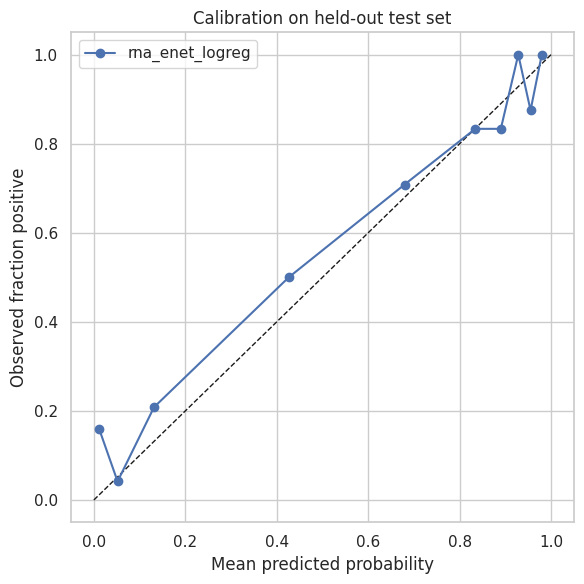

In [30]:
calibration_rows = []
plot_models = [PRIMARY_MODEL_NAME] + ([best_joint_model] if best_joint_model is not None and best_joint_model != PRIMARY_MODEL_NAME else [])

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", linewidth=1)

for model_name in plot_models:
    prob = test_prob_store[model_name]
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=model_name)
    calibration_rows.append(
        {
            "model_name": model_name,
            "brier_score": brier_score_loss(y_test, prob),
        }
    )

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed fraction positive")
ax.set_title("Calibration on held-out test set")
ax.legend()
plt.tight_layout()

calibration_df = pd.DataFrame(calibration_rows)
display(calibration_df.round(4))


## 14. Task 2: multiclass TP53 mutation-type prediction with lineage-stratified splitting

This section addresses the assignment's second task: predicting the **type of TP53 mutation** from gene expression profiles.

A literal mutation-type task could try to separate many raw categories such as missense, nonsense, frameshift deletion, frameshift insertion, splice-site, in-frame insertion, and in-frame deletion. In practice, several of these exact categories are rare, so modelling each one separately would create unstable classes. Therefore, I use broader TP53 mutation-type/consequence groups that preserve the main biological distinction while keeping enough samples per class.

For CCLE, the Task 2 classes are:

- `wild_type`: no protein-altering TP53 event used for the primary label;
- `missense_or_inframe`: missense or in-frame TP53 alterations, which often preserve protein length but alter amino-acid sequence or local structure;
- `lof_or_splice`: loss-of-function-like events, including truncating, frameshift, nonsense, or splice-related events.

The 3-class formulation evaluates whether RNA expression can distinguish WT, missense/in-frame, and loss-of-function/splice-like TP53 states. Because this still includes WT, the notebook also reports a stricter **mutant-only Task 2** evaluation on held-out TP53-mutant samples only. That stricter report compares `missense_or_inframe` versus `lof_or_splice`, which more directly matches the phrase "type of mutation."

For Task 2, I rebuild the split specifically for mutation-type prediction and stratify by **TP53 mutation-type class x CCLE lineage** where possible. This preserves both mutation-type class balance and major lineage composition across train, validation, and test sets. Rare lineage-by-mutation-type strata are collapsed when necessary; they are not used to make strong per-lineage claims.

Metric note: the strict mutant-only evaluation uses the best 3-class model evaluated only on mutant test samples. If the 3-class model predicts `wild_type` for a mutant sample, that prediction is counted as an error in the metrics. The displayed mutant-only confusion table focuses on the two mutant classes, so the full 3-class confusion matrix should be used when interpreting WT-predicted errors.

In [31]:
# ============================================================
# Task 2: true multiclass TP53 mutation-type prediction in CCLE
# ============================================================
# Methodological change from the initial completed version:
#   * Task 2 gets its own train/validation/test split.
#   * The split is stratified by TP53 mutation-type label and CCLE lineage together.
#   * Hyperparameter CV also stratifies by the same label-lineage strata when feasible.
#   * Model selection is by validation macro-F1, not by test performance.

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

TASK2_LABEL_COL = "TP53_task2_label"
TASK2_TEST_SIZE = 0.15
TASK2_VAL_SIZE = 0.15

if TASK2_LABEL_COL not in sample_meta.columns:
    if "mut_type" in sample_meta.columns:
        sample_meta[TASK2_LABEL_COL] = sample_meta["mut_type"].astype(str)
    elif "TP53_event_class" in sample_meta.columns:
        sample_meta[TASK2_LABEL_COL] = sample_meta["TP53_event_class"].fillna("wild_type").astype(str)
    else:
        raise ValueError("Cannot construct CCLE Task 2 label: missing mut_type/TP53_event_class.")

# Final CCLE Task 2 classes from the EDA notebook.
task2_labels = ["wild_type", "missense_or_inframe", "lof_or_splice"]

unexpected_task2 = sorted(set(sample_meta[TASK2_LABEL_COL].dropna().astype(str)) - set(task2_labels))
if unexpected_task2:
    raise ValueError(f"Unexpected CCLE Task 2 labels: {unexpected_task2}")

if lineage_col is None or lineage_col not in sample_meta.columns:
    raise ValueError(
        "Task 2 now requires a CCLE lineage column for label-lineage stratification. "
        "Check the EDA schema and sample metadata."
    )


def make_stable_joint_strata(
    labels,
    groups,
    min_count=2,
    group_name="group",
    split_fraction=None,
    min_group_count=10,
    max_unique_strata=None,
):
    """Create adaptive label x group strata without dropping samples.

    Strict label-by-lineage strata can be too granular when some lineages or
    label-lineage cells are small. This helper keeps all samples, collapses
    rare groups/cells into a rare bucket, and only falls back to label-only
    stratification if the joint strata are still unsafe for the requested split.

    Parameters
    ----------
    labels : array-like
        Target labels used for stratification.
    groups : array-like
        Lineage/cancer-type groups used as strata, not predictors.
    min_count : int
        Minimum count required in each final stratum. For k-fold CV, pass k.
    split_fraction : float or None
        Fraction used for the smaller split. When provided, the helper also
        limits the number of unique strata so sklearn can allocate at least one
        sample per stratum in the split.
    min_group_count : int
        Overall group size below which a lineage/cancer type is collapsed to a
        rare bucket before constructing label x group strata.
    """
    labels = pd.Series(labels).astype(str)
    groups = (
        pd.Series(groups, index=labels.index)
        .astype(str)
        .fillna("missing")
        .replace({"nan": "missing", "None": "missing"})
    )

    n = len(labels)
    min_count = int(max(2, min_count))

    if split_fraction is not None:
        split_fraction = float(split_fraction)
        n_small = int(np.ceil(n * min(split_fraction, 1 - split_fraction)))
        # sklearn requires n_train and n_test to be >= number of strata.
        max_unique_by_split = max(2, n_small)
    else:
        max_unique_by_split = n

    if max_unique_strata is None:
        max_unique_strata = max_unique_by_split
    else:
        max_unique_strata = min(int(max_unique_strata), max_unique_by_split)

    # Try increasingly broad rare-group collapses before falling back to labels only.
    candidate_min_group_counts = sorted(set([int(min_group_count), 15, 25, 40, 60, 100, 10**9]))

    for threshold in candidate_min_group_counts:
        group_counts = groups.value_counts(dropna=False)
        if threshold >= 10**9:
            groups_collapsed = pd.Series(f"RARE_{group_name.upper()}", index=groups.index)
        else:
            groups_collapsed = groups.where(groups.map(group_counts) >= threshold, f"RARE_{group_name.upper()}")

        joint = labels + "__" + groups_collapsed
        rare_joint = joint.value_counts(dropna=False).loc[lambda s: s < min_count].index
        if len(rare_joint) > 0:
            groups_collapsed = groups_collapsed.copy()
            groups_collapsed.loc[joint.isin(rare_joint)] = f"RARE_{group_name.upper()}"
            joint = labels + "__" + groups_collapsed

        counts = joint.value_counts(dropna=False)
        if counts.min() >= min_count and counts.shape[0] <= max_unique_strata:
            print(
                f"Using adaptive TP53-label x {group_name} strata: "
                f"{counts.shape[0]} strata; rare {group_name} threshold={threshold}. "
                f"No samples dropped."
            )
            return joint

    print(
        f"Warning: TP53-label x {group_name} strata are too sparse for this split/CV; "
        "falling back to TP53-label-only stratification. No samples dropped."
    )
    return labels

task2_counts = (
    sample_meta[TASK2_LABEL_COL]
    .value_counts()
    .reindex(task2_labels)
    .rename_axis("TP53_task2_label")
    .to_frame("n")
)

# Task 2 uses all eligible samples but creates a new split that is adaptively stratified by
# mutation-type class and lineage. Rare lineage-type cells are collapsed; no samples are
# dropped solely because a lineage stratum is small.
y2_all = sample_meta[TASK2_LABEL_COL].astype(str)
task2_all_idx = pd.Index(sample_meta.index[y2_all.isin(task2_labels)], name=sample_meta.index.name)
task2_lineage_all = (
    sample_meta.loc[task2_all_idx, lineage_col]
    .astype(str)
    .fillna("missing")
    .replace({"nan": "missing"})
)

task2_strata_all = make_stable_joint_strata(
    labels=y2_all.loc[task2_all_idx],
    groups=task2_lineage_all,
    min_count=2,
    group_name="lineage",
    split_fraction=TASK2_TEST_SIZE,
    min_group_count=15,
)

task2_trainval_idx, task2_test_idx = train_test_split(
    task2_all_idx,
    test_size=TASK2_TEST_SIZE,
    random_state=RNG,
    shuffle=True,
    stratify=task2_strata_all,
)

task2_trainval_idx = pd.Index(task2_trainval_idx, name=sample_meta.index.name)
task2_test_idx = pd.Index(task2_test_idx, name=sample_meta.index.name)

task2_trainval_strata = make_stable_joint_strata(
    labels=y2_all.loc[task2_trainval_idx],
    groups=sample_meta.loc[task2_trainval_idx, lineage_col],
    min_count=2,
    group_name="lineage",
    split_fraction=TASK2_VAL_SIZE / (1.0 - TASK2_TEST_SIZE),
    min_group_count=15,
)

task2_val_fraction_of_trainval = TASK2_VAL_SIZE / (1.0 - TASK2_TEST_SIZE)
task2_train_idx, task2_val_idx = train_test_split(
    task2_trainval_idx,
    test_size=task2_val_fraction_of_trainval,
    random_state=RNG,
    shuffle=True,
    stratify=task2_trainval_strata,
)

task2_train_idx = pd.Index(task2_train_idx, name=sample_meta.index.name)
task2_val_idx = pd.Index(task2_val_idx, name=sample_meta.index.name)
task2_trainval_idx = task2_train_idx.union(task2_val_idx)

# Feature matrices for Task 2.
X2_train = X_joint.loc[task2_train_idx]
X2_val = X_joint.loc[task2_val_idx]
X2_test = X_joint.loc[task2_test_idx]
X2_trainval = X_joint.loc[task2_trainval_idx]

X2_meta_all = sample_meta[[lineage_col]].copy()
X2_meta_all[lineage_col] = X2_meta_all[lineage_col].astype(str).fillna("missing").replace({"nan": "missing"})
X2_meta_train = X2_meta_all.loc[task2_train_idx]
X2_meta_val = X2_meta_all.loc[task2_val_idx]
X2_meta_test = X2_meta_all.loc[task2_test_idx]
X2_meta_trainval = X2_meta_all.loc[task2_trainval_idx]

y2_train = y2_all.loc[task2_train_idx]
y2_val = y2_all.loc[task2_val_idx]
y2_test = y2_all.loc[task2_test_idx]
y2_trainval = y2_all.loc[task2_trainval_idx]

split_task2_counts = pd.concat(
    {
        "train": y2_train.value_counts().reindex(task2_labels),
        "val": y2_val.value_counts().reindex(task2_labels),
        "test": y2_test.value_counts().reindex(task2_labels),
    },
    axis=1,
).fillna(0).astype(int)

task2_lineage_split_counts = pd.concat(
    {
        "train": X2_meta_train[lineage_col].value_counts(),
        "val": X2_meta_val[lineage_col].value_counts(),
        "test": X2_meta_test[lineage_col].value_counts(),
    },
    axis=1,
).fillna(0).astype(int).sort_values("train", ascending=False)

print("CCLE Task 2 class counts:")
display(task2_counts)
print("CCLE Task 2 split counts using label-lineage stratification:")
display(split_task2_counts)
print("CCLE Task 2 lineage split counts, top 20 lineages:")
display(task2_lineage_split_counts.head(20))


def align_multiclass_proba(estimator, X, labels):
    """Return probability columns aligned to a fixed class order."""
    labels = list(labels)
    if hasattr(estimator, "predict_proba"):
        raw = estimator.predict_proba(X)
        est_classes = list(estimator.classes_)
    elif hasattr(estimator, "decision_function"):
        score = np.asarray(estimator.decision_function(X), dtype=float)
        if score.ndim == 1:
            score = np.column_stack([-score, score])
        score = score - np.nanmax(score, axis=1, keepdims=True)
        exp_score = np.exp(score)
        raw = exp_score / np.clip(exp_score.sum(axis=1, keepdims=True), 1e-12, None)
        est_classes = list(estimator.classes_)
    else:
        pred = estimator.predict(X)
        raw = np.zeros((len(pred), len(labels)), dtype=float)
        est_classes = labels
        for i, p in enumerate(pred):
            if p in labels:
                raw[i, labels.index(p)] = 1.0

    out = np.zeros((raw.shape[0], len(labels)), dtype=float)
    for j, cls in enumerate(labels):
        if cls in est_classes:
            out[:, j] = raw[:, est_classes.index(cls)]
    out = out / np.clip(out.sum(axis=1, keepdims=True), 1e-12, None)
    return out


def evaluate_multiclass(y_true, proba, labels):
    y_true = pd.Series(y_true).astype(str).to_numpy()
    labels = list(labels)
    y_pred = np.asarray(labels, dtype=object)[np.argmax(proba, axis=1)]

    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    try:
        y_bin = label_binarize(y_true, classes=labels)
        out["ovr_auroc_macro"] = roc_auc_score(y_bin, proba, average="macro", multi_class="ovr")
        out["ovr_auprc_macro"] = average_precision_score(y_bin, proba, average="macro")
    except Exception as exc:
        out["ovr_auroc_macro"] = np.nan
        out["ovr_auprc_macro"] = np.nan
        out["auc_note"] = repr(exc)

    return out, y_pred


def multiclass_report_df(y_true, y_pred, labels):
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).T.reset_index().rename(columns={"index": "class"})


class RNAMulticlassKBestFeatureBuilder(BaseEstimator, TransformerMixin):
    """Fold-safe multiclass RNA feature builder using train-fold ANOVA F scores."""

    def __init__(self, rna_cols, k=1000):
        self.rna_cols = rna_cols
        self.k = k

    def fit(self, X, y):
        X_df = self._to_frame(X)
        self.rna_cols_ = list(self.rna_cols)
        X_rna = X_df.loc[:, self.rna_cols_]
        k_eff = min(int(self.k), X_rna.shape[1])

        self.selector_ = SelectKBest(score_func=f_classif, k=k_eff)
        X_selected = self.selector_.fit_transform(X_rna, y)

        self.scaler_ = StandardScaler()
        self.scaler_.fit(X_selected)

        self.selected_genes_ = np.asarray(self.rna_cols_)[self.selector_.get_support()]
        return self

    def transform(self, X):
        X_df = self._to_frame(X)
        X_rna = X_df.loc[:, self.rna_cols_]
        X_selected = self.selector_.transform(X_rna)
        return self.scaler_.transform(X_selected)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.selected_genes_, dtype=object)

    @staticmethod
    def _to_frame(X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("RNAMulticlassKBestFeatureBuilder expects a pandas DataFrame")
        return X


def make_task2_rna_pipeline(clf, rna_cols, k=1000):
    return Pipeline(
        steps=[
            ("features", RNAMulticlassKBestFeatureBuilder(rna_cols=rna_cols, k=k)),
            ("clf", clf),
        ]
    )


task2_cv_n = min(CONFIG["cv_splits"], int(y2_train.value_counts().min()))
task2_cv_strata = make_stable_joint_strata(
    labels=y2_train,
    groups=X2_meta_train[lineage_col],
    min_count=task2_cv_n,
    group_name="lineage",
)
task2_cv = list(
    StratifiedKFold(n_splits=task2_cv_n, shuffle=True, random_state=RNG).split(
        np.zeros(len(y2_train)),
        task2_cv_strata,
    )
)

# Each registry entry declares the feature matrix it uses. Lineage is used for
# stratified splitting/auditing only, not as a predictor.
task2_registry = [
    {
        "model_name": "task2_dummy_prior",
        "tier": "baseline",
        "feature_set": "rna",
        "estimator": DummyClassifier(strategy="prior"),
        "param_grid": {},
    },
    {
        "model_name": "task2_rna_multinomial_logreg",
        "tier": "mrna",
        "feature_set": "rna",
        "estimator": make_task2_rna_pipeline(
            LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                max_iter=8000,
                class_weight="balanced",
                random_state=RNG,
            ),
            rna_cols=rna_cols,
            k=1000,
        ),
        "param_grid": {
            "features__k": [500, 1000, 2000],
            "clf__C": [0.03, 0.1, 0.3],
            "clf__l1_ratio": [0.0, 0.5],
        },
    },
    {
        "model_name": "task2_rna_linear_svm",
        "tier": "mrna",
        "feature_set": "rna",
        "estimator": make_task2_rna_pipeline(
            SVC(
                kernel="linear",
                probability=True,
                class_weight="balanced",
                random_state=RNG,
            ),
            rna_cols=rna_cols,
            k=1000,
        ),
        "param_grid": {
            "features__k": [500, 1000],
            "clf__C": [0.03, 0.1, 0.3],
        },
    },
]

task2_feature_sets = {
    "rna": {
        "train": X2_train,
        "val": X2_val,
        "test": X2_test,
        "trainval": X2_trainval,
    },
}

assert all(spec["feature_set"] == "rna" for spec in task2_registry), "Task 2 metadata predictors are disabled; all models must use RNA feature sets."

task2_val_rows = []
task2_test_rows = []
task2_best_estimators = {}
task2_best_params = {}

for spec in task2_registry:
    name = spec["model_name"]
    est = clone(spec["estimator"])
    grid = spec["param_grid"]
    feature_set = spec["feature_set"]
    X_fit = task2_feature_sets[feature_set]["train"]

    if len(grid) > 0:
        search = GridSearchCV(
            estimator=est,
            param_grid=grid,
            scoring="f1_macro",
            cv=task2_cv,
            n_jobs=-1,
            refit=True,
        )
        search.fit(X_fit, y2_train)
        best_est = search.best_estimator_
        best_params = search.best_params_
        best_cv = search.best_score_
    else:
        best_est = est.fit(X_fit, y2_train)
        best_params = {}
        best_cv = np.nan

    val_proba = align_multiclass_proba(best_est, task2_feature_sets[feature_set]["val"], task2_labels)
    val_metrics, _ = evaluate_multiclass(y2_val, val_proba, task2_labels)

    task2_val_rows.append(
        {
            "model_name": name,
            "tier": spec["tier"],
            "feature_set": feature_set,
            "cv_best_macro_f1": best_cv,
            "best_params": json.dumps(best_params),
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
    )

    # Refit on train + validation using the selected hyperparameters before the one-time test evaluation.
    refit_est = clone(spec["estimator"])
    if len(best_params) > 0:
        refit_est.set_params(**best_params)
    refit_est.fit(task2_feature_sets[feature_set]["trainval"], y2_trainval)

    test_proba = align_multiclass_proba(refit_est, task2_feature_sets[feature_set]["test"], task2_labels)
    test_metrics, test_pred = evaluate_multiclass(y2_test, test_proba, task2_labels)

    task2_test_rows.append(
        {
            "model_name": name,
            "tier": spec["tier"],
            "feature_set": feature_set,
            "cv_best_macro_f1": best_cv,
            "best_params": json.dumps(best_params),
            **{f"test_{k}": v for k, v in test_metrics.items()},
        }
    )

    task2_best_estimators[name] = refit_est
    task2_best_params[name] = best_params

task2_val_results = pd.DataFrame(task2_val_rows).sort_values(
    "val_macro_f1",
    ascending=False,
).reset_index(drop=True)

task2_validation_order = {name: rank for rank, name in enumerate(task2_val_results["model_name"], start=1)}
task2_test_results = pd.DataFrame(task2_test_rows)
task2_test_results["validation_rank"] = task2_test_results["model_name"].map(task2_validation_order)
task2_test_results = task2_test_results.sort_values("validation_rank").reset_index(drop=True)

display(task2_val_results.round(4))
display(task2_test_results.round(4))

best_task2_name = task2_val_results.iloc[0]["model_name"]
best_task2_feature_set = task2_val_results.iloc[0]["feature_set"]
best_task2_est = task2_best_estimators[best_task2_name]
best_task2_test_proba = align_multiclass_proba(
    best_task2_est,
    task2_feature_sets[best_task2_feature_set]["test"],
    task2_labels,
)
_, best_task2_test_pred = evaluate_multiclass(y2_test, best_task2_test_proba, task2_labels)

task2_confusion = pd.DataFrame(
    confusion_matrix(y2_test, best_task2_test_pred, labels=task2_labels),
    index=[f"true_{x}" for x in task2_labels],
    columns=[f"pred_{x}" for x in task2_labels],
)

task2_report = multiclass_report_df(y2_test, best_task2_test_pred, task2_labels)

print(f"Best CCLE Task 2 model by validation macro-F1: {best_task2_name}")
display(task2_confusion)
display(task2_report.round(4))

# Strict assignment-aligned Task 2: evaluate mutation type among TP53-mutant samples only.
# The model is still the same held-out test model selected above; WT samples are removed only for this metric.
ccle_task2_mutant_labels = ["missense_or_inframe", "lof_or_splice"]
ccle_task2_mutant_mask = pd.Series(y2_test).astype(str).ne("wild_type").to_numpy()
ccle_task2_mutant_y_true = pd.Series(y2_test).astype(str).to_numpy()[ccle_task2_mutant_mask]
ccle_task2_mutant_y_pred = pd.Series(best_task2_test_pred).astype(str).to_numpy()[ccle_task2_mutant_mask]

ccle_task2_mutant_only_metrics = pd.DataFrame([
    {
        "cohort": "CCLE",
        "evaluation": "mutant_only_task2",
        "best_model": best_task2_name,
        "n_mutant_test_samples": int(ccle_task2_mutant_mask.sum()),
        "labels": json.dumps(ccle_task2_mutant_labels),
        "accuracy": accuracy_score(ccle_task2_mutant_y_true, ccle_task2_mutant_y_pred),
        "balanced_accuracy": balanced_accuracy_score(ccle_task2_mutant_y_true, ccle_task2_mutant_y_pred),
        "macro_f1": f1_score(
            ccle_task2_mutant_y_true,
            ccle_task2_mutant_y_pred,
            average="macro",
            labels=ccle_task2_mutant_labels,
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            ccle_task2_mutant_y_true,
            ccle_task2_mutant_y_pred,
            average="weighted",
            labels=ccle_task2_mutant_labels,
            zero_division=0,
        ),
    }
])

ccle_task2_mutant_only_confusion = pd.DataFrame(
    confusion_matrix(
        ccle_task2_mutant_y_true,
        ccle_task2_mutant_y_pred,
        labels=ccle_task2_mutant_labels,
    ),
    index=[f"true_{x}" for x in ccle_task2_mutant_labels],
    columns=[f"pred_{x}" for x in ccle_task2_mutant_labels],
)

ccle_task2_mutant_only_report = multiclass_report_df(
    ccle_task2_mutant_y_true,
    ccle_task2_mutant_y_pred,
    ccle_task2_mutant_labels,
)

print("Strict CCLE Task 2 mutant-only evaluation: missense/in-frame vs LOF/splice")
display(ccle_task2_mutant_only_metrics.round(4))
display(ccle_task2_mutant_only_confusion)
display(ccle_task2_mutant_only_report.round(4))


Using adaptive TP53-label x lineage strata: 71 strata; rare lineage threshold=15. No samples dropped.
Using adaptive TP53-label x lineage strata: 71 strata; rare lineage threshold=15. No samples dropped.
CCLE Task 2 class counts:


,n
TP53_task2_label,
wild_type,621
missense_or_inframe,625
lof_or_splice,362


CCLE Task 2 split counts using label-lineage stratification:


,train,val,test
TP53_task2_label,,,
wild_type,434,93,94
missense_or_inframe,436,94,95
lof_or_splice,254,55,53


CCLE Task 2 lineage split counts, top 20 lineages:


...

Strict CCLE Task 2 mutant-only evaluation: missense/in-frame vs LOF/splice


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,cohort,evaluation,best_model,n_mutant_test_samples,labels,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,CCLE,mutant_only_task2,task2_rna_multinomial_logreg,148,"[""missense_or_inframe"", ""lof_or_splice""]",0.8176,0.8162,0.8525,0.8552


,pred_missense_or_inframe,pred_lof_or_splice
true_missense_or_inframe,78,6
true_lof_or_splice,8,43


,class,precision,recall,f1-score,support
0,missense_or_inframe,0.9070,0.8211,0.8619,95.0
1,lof_or_splice,0.8776,0.8113,0.8431,53.0
2,micro avg,0.8963,0.8176,0.8551,148.0
3,macro avg,0.8923,0.8162,0.8525,148.0
4,weighted avg,0.8964,0.8176,0.8552,148.0


## 15. CCLE final project conclusions

The CCLE analysis explicitly separates the two assignment tasks.

**Task 1** predicts binary TP53 nonsynonymous/protein-altering mutation status from RNA expression. The primary models are RNA-only. Lineage is used for stratification, auditing, subgroup analysis, and grouped robustness checks, but not as a predictor in the main RNA model.

**Task 2** predicts coarse TP53 mutation-type/consequence classes from RNA expression. The 3-class model distinguishes `wild_type`, `missense_or_inframe`, and `lof_or_splice`. To address a stricter reading of the assignment, the notebook also reports a mutant-only Task 2 evaluation comparing `missense_or_inframe` versus `lof_or_splice` only among TP53-mutant held-out samples.

The CCLE Task 2 results are encouraging. The best 3-class RNA model reaches approximately 0.82 test accuracy, 0.82 balanced accuracy, 0.81 macro-F1, and 0.93 one-vs-rest macro AUROC. The strict mutant-only Task 2 evaluation gives approximately 0.85 macro-F1 for distinguishing missense/in-frame from LOF/splice-like events. These results support the conclusion that RNA expression carries information about broad TP53 mutation consequences, not only binary TP53 mutation status.

The biological interpretation remains cautious. Important RNA features include plausible TP53 pathway genes and p53-response genes, but feature importance should not be interpreted causally. A gene may be predictive because it is downstream of TP53, correlated with proliferation or DNA-damage response, associated with lineage, or linked to other cancer-context effects. The lineage-stratified split, per-lineage checks, metadata audits, and grouped evaluation are included specifically to reduce and assess this confounding risk.

Overall, the CCLE part of the project supports the main claim that TP53 mutation status is predictable from RNA expression, while also showing that mutation-type prediction is feasible but more challenging and should be evaluated with macro-averaged metrics and per-class reports.

## 16. Save outputs for reporting


In [32]:
save_df_map = {
    "ccle_mrna_first_validation_results.csv": val_results,
    "ccle_mrna_first_test_results.csv": test_results,
    "ccle_mrna_first_main_comparison.csv": main_comparison,
    "ccle_mrna_first_bootstrap_summary.csv": bootstrap_summary,
    "ccle_mrna_first_primary_coefficients.csv": primary_coef_df,
}

for fname, df in save_df_map.items():
    df.to_csv(PROC / fname, index=False)


if ccle_ablation_table is not None:
    ccle_ablation_table.to_csv(PROC / "ccle_mrna_first_ablation_table.csv", index=False)
if ccle_ablation_table_with_ensemble is not None:
    ccle_ablation_table_with_ensemble.to_csv(PROC / "ccle_mrna_first_ablation_table_with_ensemble.csv", index=False)
if isinstance(ccle_ablation_cv_results, pd.DataFrame) and len(ccle_ablation_cv_results) > 0:
    ccle_ablation_cv_results.to_csv(PROC / "ccle_mrna_first_ablation_cv_results.csv", index=False)
if ccle_final_model_comparison_with_ablations is not None:
    ccle_final_model_comparison_with_ablations.to_csv(PROC / "ccle_mrna_first_final_comparison_with_ablations.csv", index=False)

if joint_coef_df is not None:
    joint_coef_df.to_csv(PROC / "ccle_mrna_first_joint_coefficients.csv", index=False)
if per_lineage_primary is not None and len(per_lineage_primary) > 0:
    per_lineage_primary.to_csv(PROC / "ccle_mrna_first_per_lineage_primary.csv", index=False)
if grouped_cv_folds is not None:
    grouped_cv_folds.to_csv(PROC / "ccle_mrna_first_grouped_cv_folds.csv", index=False)
if grouped_cv_summary is not None:
    grouped_cv_summary.to_csv(PROC / "ccle_mrna_first_grouped_cv_summary.csv")
if outlier_sensitivity is not None:
    outlier_sensitivity.to_csv(PROC / "ccle_mrna_first_outlier_sensitivity.csv", index=False)
if label_sensitivity is not None:
    label_sensitivity.to_csv(PROC / "ccle_mrna_first_label_sensitivity.csv", index=False)
if calibration_df is not None:
    calibration_df.to_csv(PROC / "ccle_mrna_first_calibration.csv", index=False)


# Task 2 outputs are created only after the Task 2 section has run.
if "task2_counts" in globals():
    task2_counts.to_csv(PROC / "ccle_task2_class_counts.csv")
if "split_task2_counts" in globals():
    split_task2_counts.to_csv(PROC / "ccle_task2_split_class_counts.csv")
if "task2_val_results" in globals():
    task2_val_results.to_csv(PROC / "ccle_task2_validation_results.csv", index=False)
if "task2_test_results" in globals():
    task2_test_results.to_csv(PROC / "ccle_task2_test_results.csv", index=False)
if "task2_confusion" in globals():
    task2_confusion.to_csv(PROC / "ccle_task2_confusion_matrix.csv")
if "task2_report" in globals():
    task2_report.to_csv(PROC / "ccle_task2_classification_report.csv", index=False)
if "ccle_task2_mutant_only_metrics" in globals():
    ccle_task2_mutant_only_metrics.to_csv(PROC / "ccle_task2_mutant_only_metrics.csv", index=False)
if "ccle_task2_mutant_only_confusion" in globals():
    ccle_task2_mutant_only_confusion.to_csv(PROC / "ccle_task2_mutant_only_confusion_matrix.csv")
if "ccle_task2_mutant_only_report" in globals():
    ccle_task2_mutant_only_report.to_csv(PROC / "ccle_task2_mutant_only_classification_report.csv", index=False)

final_predictions = pd.DataFrame(index=X_test.index)
final_predictions["y_true"] = y_test
for model_name, prob in test_prob_store.items():
    final_predictions[f"prob__{model_name}"] = prob
save_parquet_with_id(final_predictions, "ccle_mrna_first_test_predictions.parquet")

run_summary = {
    "primary_label": primary_label,
    "primary_model_name": PRIMARY_MODEL_NAME,
    "best_metadata_model": best_meta_model,
    "best_joint_model": best_joint_model,
    "rna_gene_count": len(rna_cols),
    "recommended_meta_cols": recommended_meta_cols,
    "main_models": main_models,
    "has_ablation_table": bool(ccle_ablation_table is not None),
    "has_tp53_event_class": "TP53_event_class" in sample_meta.columns,
    "has_tp53_mut_ambiguous": "TP53_mut_ambiguous" in sample_meta.columns,
    "ambiguous_tp53_n": int(sample_meta["TP53_mut_ambiguous"].sum()) if "TP53_mut_ambiguous" in sample_meta.columns else None,
    "task2_label": TASK2_LABEL_COL if "TASK2_LABEL_COL" in globals() else None,
    "task2_classes": task2_labels if "task2_labels" in globals() else None,
    "best_task2_model": best_task2_name if "best_task2_name" in globals() else None,
    "has_task2_mutant_only_metrics": bool("ccle_task2_mutant_only_metrics" in globals()),
}
with open(PROC / "ccle_mrna_first_run_summary.json", "w") as f:
    json.dump(run_summary, f, indent=2)

print("Saved revised mRNA-first modeling artifacts to:", PROC.resolve())


Saved revised mRNA-first modeling artifacts to: /kaggle/working/processed
